# 202235203 고수호
# **5week - breast_cancer.csv 데이터에 대한 DL_Classification**

# **# 라이브러리 임포트**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

# **# 데이터 세트 불러오기**

In [2]:
path = '/content/drive/MyDrive/Colab Notebooks/5week/breast_cancer.csv'
df = pd.read_csv(path, index_col = 0)
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


# **# Feature Selection을 위한 상관관계 확인**

<Axes: >

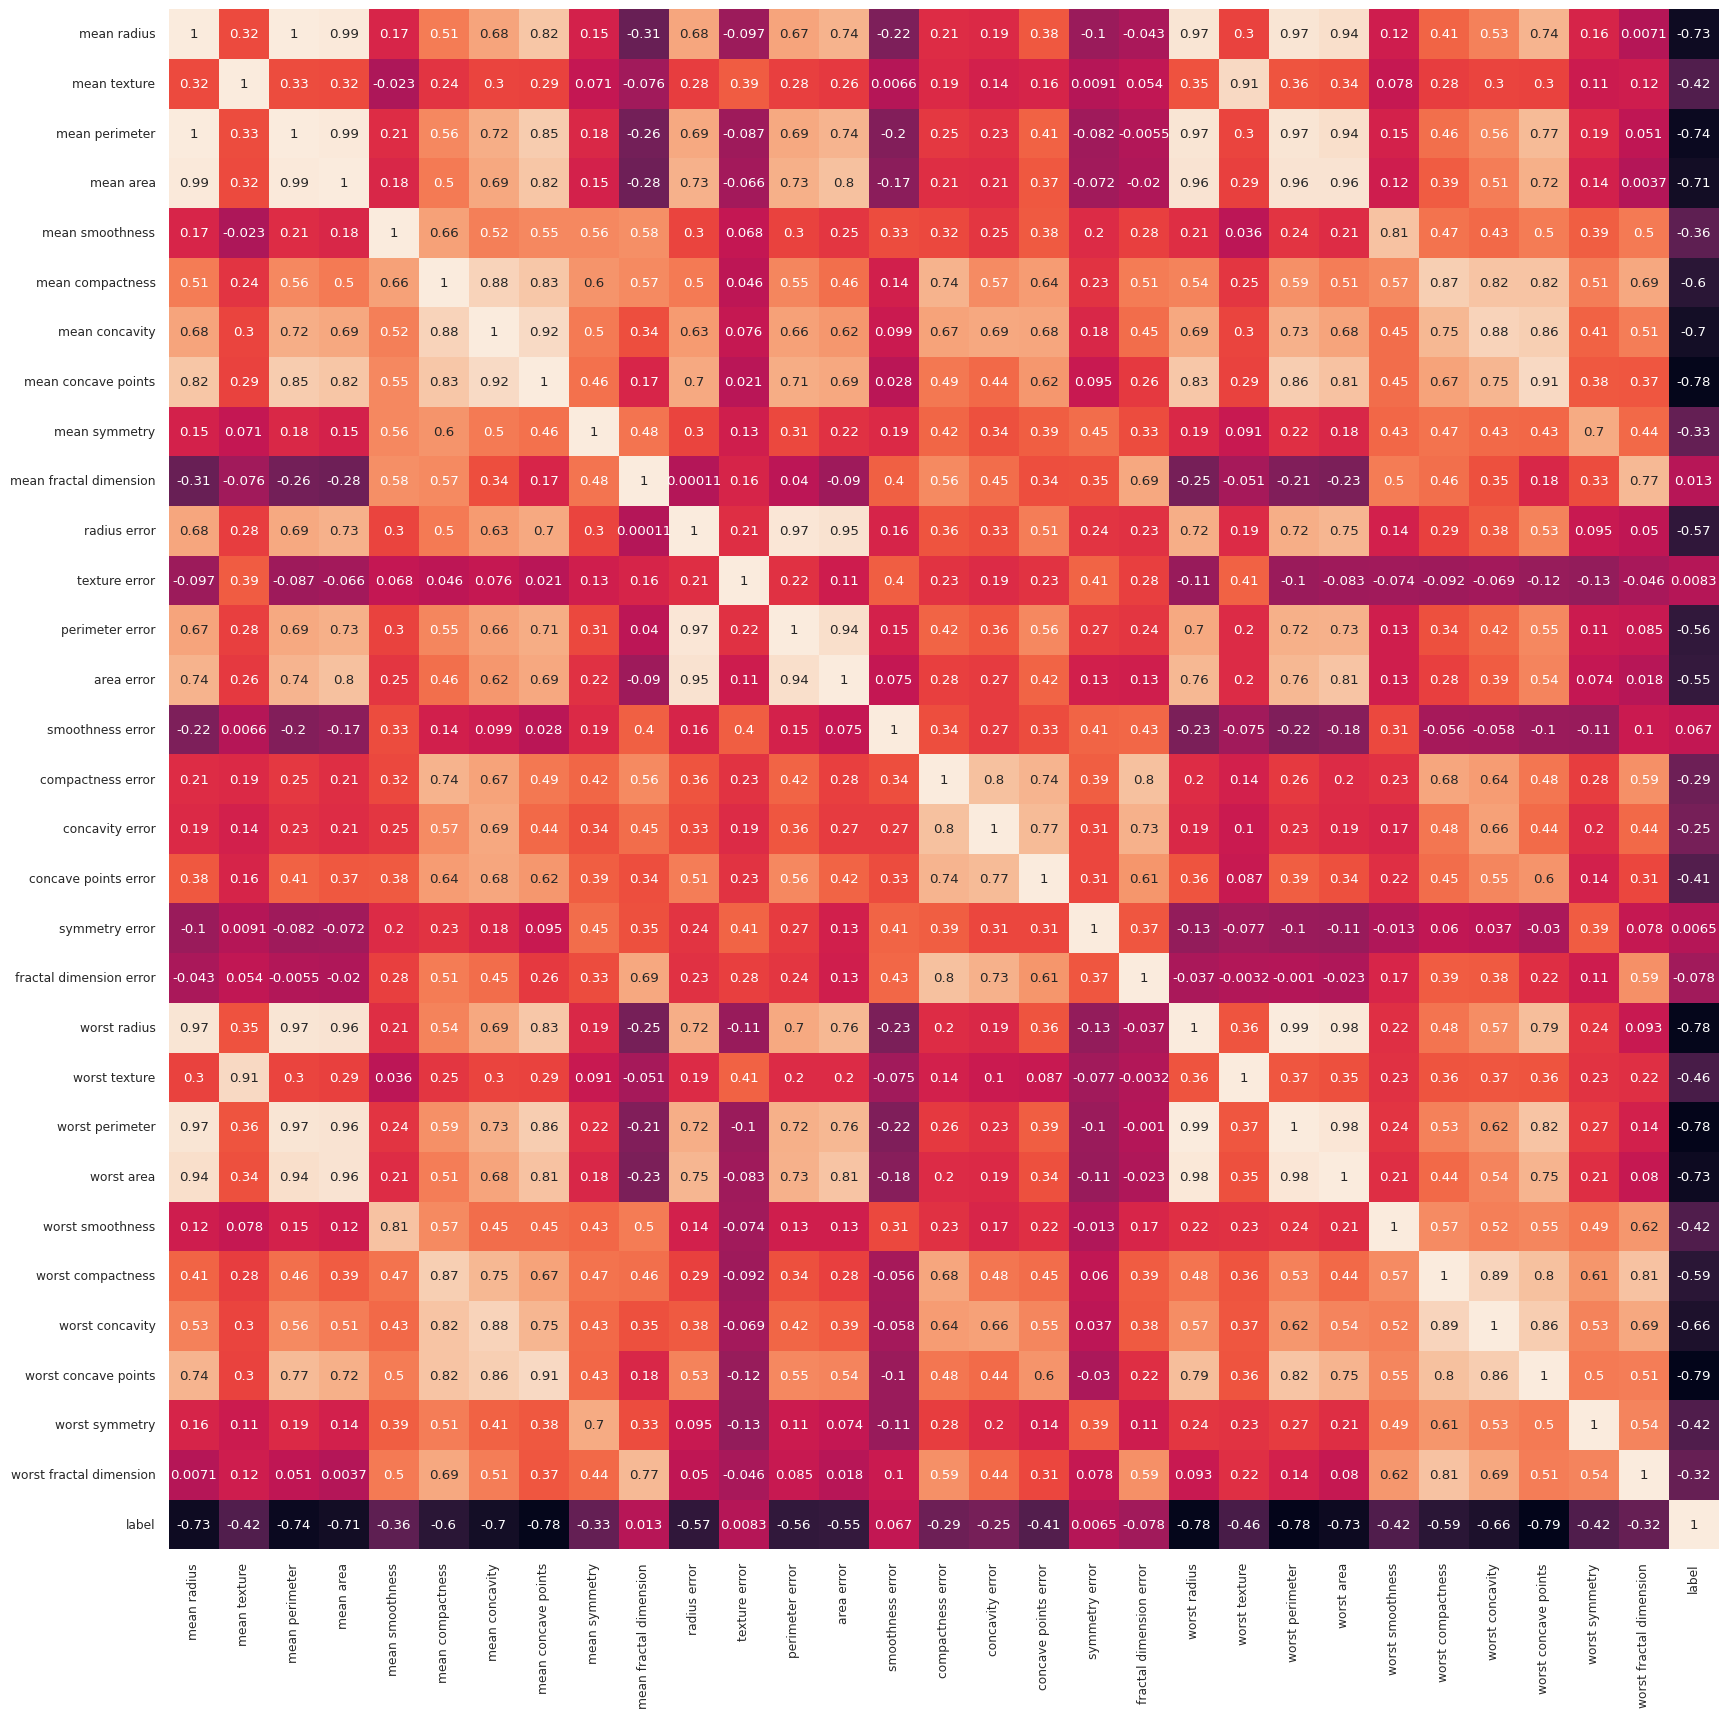

In [3]:
df_corr = df.corr()
plt.figure(figsize=(20,20))
sns.set(font_scale = 0.8)
sns.heatmap(df_corr, annot=True, cbar=False)

# **# 결측치 확인**

In [4]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


# **# 종속변수(y) 설정**

In [5]:
y=df['label']
y.value_counts()

,count
label,
1,357
0,212


# **# 원-핫 인코딩**

In [6]:
Y = pd.get_dummies(y).values

# **# 독립변수(X) 설정 및 Feature Selection**

In [7]:
X=df.drop(['label', 'mean fractal dimension', 'texture error', 'smoothness error', 'symmetry error', 'fractal dimension error'], axis=1)
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,radius error,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,1.0950,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.5435,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.7456,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.4956,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.7572,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# **# 딥러닝 입력을 위해 Numpy 배열로 변환**

In [8]:
X = X.values

# **# 데이터셋 분리 (Training & Test Set)**

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

# **# 딥러닝 모델 구성 및 학습**

```python
model = Sequential()

model.add(Dense(10,input_shape=(X.shape[1],),activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(6,activation='relu'))
model.add(Dense(2,activation='softmax'))
```
* **Sequential** : 레이어를 순차적으로 쌓는 모델의 컨테이너 역할.
* **Dense(10, activation="relu")** : 10개의 노드를 가진 첫 번째 은닉층.
* **model.add(Dense(2,activation='softmax'))** : 출력층. 일반적인 이진 분류 문제에서는 **Sigmoid** 활성화 함수를 사용하지만 **원-핫 인코딩**을 사용하므로 **Softmax** 활성화 함수 사용

**# 학습 전략 설정**
```python
model.compile(Adam(learning_rate=0.04),'binary_crossentropy',metrics=['accuracy'])
```
* **adam** : 효율적인 학습을 위한 최적화 알고리즘.
* **binary_crossentropy** : 타겟 데이터가 **One-hot encoding**된 형태일 때 사용하는 **이진 분류** 손실 함수.
* **metrics=["accuracy"]** : 모델의 성능을 평가할 지표로 정확도(Accuracy)를 설정.  

**# 실제 학습 수행**
```python
model_history=model.fit(x=X_train, y=y_train, epochs=30, batch_size=32,validation_data= (X_test,y_test))
```
* **epochs=30** : 전체 데이터를 총 30회 반복 학습.
* **batch_size=32** : 32개의 데이터를 한 번의 가중치 업데이트 단위로 설정.
* **validation_data= (X_test,y_test)** : (X_test,y_test)값, 즉 학습에 직접 참여하지 않는 "검증용 데이터"를 통해 모델의 성능을 실시간으로 확인.

In [16]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam


model = Sequential()

model.add(Dense(10,input_shape=(X.shape[1],),activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(6,activation='relu'))
model.add(Dense(2,activation='softmax'))

model.compile(Adam(learning_rate=0.04),'binary_crossentropy',metrics=['accuracy'])

model_history=model.fit(x=X_train, y=y_train, epochs=30, batch_size=32,validation_data= (X_test,y_test))

model.summary()

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5758 - loss: 6.3538 - val_accuracy: 0.6228 - val_loss: 0.8592
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8396 - loss: 0.4481 - val_accuracy: 0.8772 - val_loss: 0.2928
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9121 - loss: 0.2371 - val_accuracy: 0.9298 - val_loss: 0.2423
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8857 - loss: 0.2961 - val_accuracy: 0.9298 - val_loss: 0.2379
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8396 - loss: 0.3230 - val_accuracy: 0.8947 - val_loss: 0.2891
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9055 - loss: 0.2443 - val_accuracy: 0.8860 - val_loss: 0.2433
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8791 - loss: 0.3045 - val_accuracy: 0.9474 - val_loss: 0.2187
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8901 - loss: 0.2746 - val_accuracy: 0.7018 - val_lo

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 10)             │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │            14 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,250 (4.89 KB)

 Trainable params: 416 (1.62 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 834 (3.26 KB)

# **# 모델 예측 및 클래스 변환**

```python
y_pred = model.predict(X_test)
```
* **model.predict(X_test)** : 학습된 모델을 사용하여 테스트 데이터(`X_test`)에 대한 예측값을 계산.
* **출력값** : 출력층의 활성화 함수가 `softmax`이므로, 각 샘플이 각 클래스에 속할 확률(0~1 사이 값)을 담은 행렬이 반환됨.

```python
y_test_class = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred, axis=1)
```
* **np.argmax(..., axis=1)** : 각 행(샘플)에서 가장 큰 값(확률)을 가진 인덱스를 반환하여 클래스 번호로 변환.
* **y_test_class** : One-hot encoding된 실제 정답(`y_test`)을 비교를 위해 원래의 레이블 번호로 복원.
* **y_pred_class** : 모델이 예측한 확률 배열에서 가장 높은 확률을 가진 클래스를 최종 예측 클래스로 결정.

In [17]:
y_pred = model.predict(X_test)

y_test_class = np.argmax(y_test,axis=1)
y_pred_class = np.argmax(y_pred,axis=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


# **# 학습 및 검증 손실 시각화**

```python
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
```
* **loss** : 매 에포크(epoch)마다 학습 데이터(Train Data)를 통해 계산된 모델의 손실값.
* **val_loss** : 매 에포크마다 검증 데이터(Validation Data)를 통해 계산된 모델의 손실값. 모델의 **과적합(Overfitting)** 여부를 판단하는 핵심 지표.
* **epochs** : 그래프의 x축으로 사용하기 위해 1부터 손실 데이터의 개수만큼의 범위를 생성.

```python
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
```
* **'y' / 'r'** : 학습 손실은 **노란색(Yellow)**, 검증 손실은 **빨간색(Red)** 선으로 표시.
* **label** : 범례(Legend)에 표시될 각 선의 이름 설정.

```python
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
```
* **plt.title** : 그래프의 제목 설정.
* **plt.xlabel / ylabel** : x축(에포크 수)과 y축(손실값)의 이름 설정.

```python
plt.legend()
plt.show()
```
* **plt.legend()** : 설정한 레이블(`Training loss`, `Validation loss`)을 그래프 내 상자에 표시.
* **plt.show()** : 구성된 그래프를 화면에 출력. 이 그래프를 통해 모델이 적절히 학습되었는지 또는 **과적합(Overfitting)**이 발생했는지 시각적으로 판단 가능.

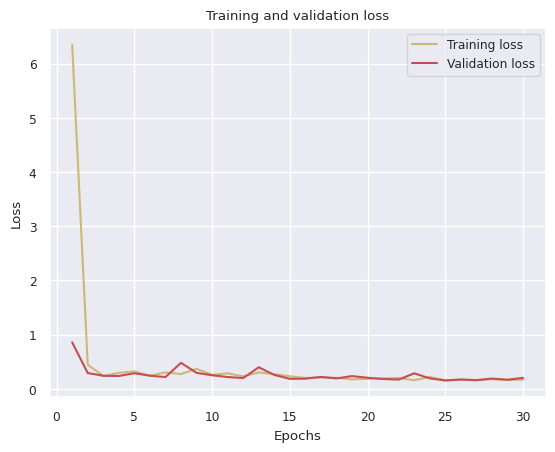

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

loss =model_history.history['loss']
val_loss =model_history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# **# 학습 및 검증 정확도 시각화**

```python
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
```
* **acc** : 학습 데이터에 대한 모델의 분류 정확도.
* **val_acc** : 검증 데이터에 대한 모델의 분류 정확도. 실제 학습에 사용되지 않은 데이터에 대해 모델이 얼마나 잘 일반화되었는지 확인.
* **역할** : 모델이 훈련 데이터와 처음 보는 데이터(검증 데이터)에 대해 얼마나 정답을 잘 맞히는지 추이를 확인.

```python
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
```
* **'y' / 'r'** : 학습 정확도는 **노란색(Yellow)**, 검증 정확도는 **빨간색(Red)** 선으로 시각화.
* **비교 포인트** : 두 선이 함께 완만하게 상승하면 학습이 잘 되는 것이나, 학습 정확도만 높고 검증 정확도가 낮다면 **과적합(Overfitting)**을 의심해야 함.

```python
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
```
* **plt.title** : 그래프의 제목을 "Training and validation accuracy"로 설정.
* **plt.xlabel / ylabel** : x축은 학습 횟수인 **Epochs**, y축은 정확도 수치인 **Accuracy**로 설정.

```python
plt.legend()
plt.show()
```
* **plt.legend()** : 그래프 우측 상단 등에 각 선의 이름(범례)을 표시.
* **plt.show()** : 최종적으로 생성된 정확도 추이 그래프를 출력.

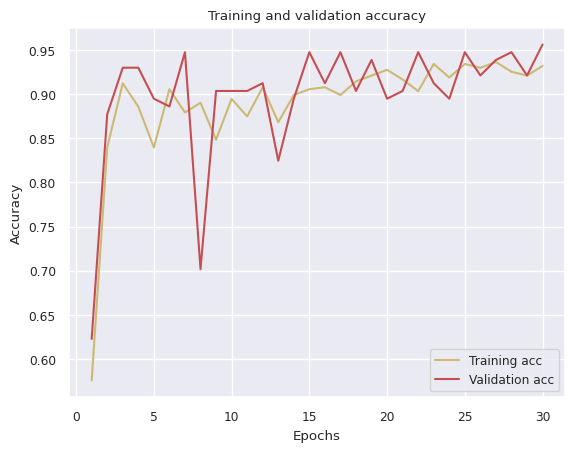

In [19]:
acc =model_history.history['accuracy']
val_acc =model_history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# **# 예측 결과 평가 및 성능 분석**

```python
from sklearn.metrics import classification_report, confusion_matrix
```
*   **classification_report**: 정밀도(Precision), 재현율(Recall), F1-score 등 분류 모델의 주요 평가 지표를 한 번에 계산하는 도구.
*   **confusion_matrix**: 오차 행렬. 실제 클래스와 모델이 예측한 클래스의 관계를 표 형태로 나타냄.

```python
print(classification_report(y_test_class, y_pred_class))
```
*   **역할**: 테스트 데이터의 실제 값(`y_test_class`)과 모델의 예측 값(`y_pred_class`)을 비교하여 종합적인 성능 보고서 출력.
*   **주요 지표**:
    *   **Precision (정밀도)**: 모델이 특정 클래스로 예측한 것 중 실제 정답인 비율.
    *   **Recall (재현율)**: 실제 정답인 데이터 중 모델이 맞춘 비율.
    *   **F1-score**: 정밀도와 재현율의 조화 평균값.

```python
print(confusion_matrix(y_test_class, y_pred_class))
```
*   **역할**: 예측 결과를 **행(실제 값)과 열(예측 값)**로 구성된 행렬로 출력하여 어떤 클래스를 혼동하고 있는지 구체적으로 파악.

In [20]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test_class,y_pred_class))
print(confusion_matrix(y_test_class,y_pred_class))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94        47
           1       0.93      1.00      0.96        67

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

[[42  5]
 [ 0 67]]
